# 1. Imports

In [4]:
import pickle
import glob
import re
import os
import json
import textwrap
import math
from types import SimpleNamespace
from collections import defaultdict
from itertools import cycle

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

from token_shap_story import TokenSHAPstory
import config

In [5]:
# --- Load Shapley values from pkl files ---
pkl_files = sorted(glob.glob("tokenshap_results/tokenshap_results_instance_*.pkl"))

dfs = {}  # {instance_id (int): DataFrame with columns [token, shapley_value, position]}

for fname in pkl_files:
    with open(fname, "rb") as f:
        tokenshap_results = pickle.load(f)

    token_shap = SimpleNamespace(**tokenshap_results)

    shap_df = pd.DataFrame([
        {"token": k.rsplit("_", 1)[0], "shapley_value": round(float(v), 4)}
        for k, v in token_shap.shapley_values.items()
    ]).assign(position=lambda df: range(len(df))) \
      .sort_values("shapley_value", ascending=False) \
      .reset_index(drop=True)

    instance_id = int(re.search(r"instance_(\d+)", fname).group(1))
    dfs[instance_id] = shap_df

# --- Load log (narratives + evaluations) ---
with open(config.LOG_JSON, "r") as f:
    log = json.load(f)

# Convenience lookup: {instance_id (int): log entry}
log_by_instance = {e["instance_index"]: e for e in log}

# Filter to evaluated entries only
log_evaluated = [e for e in log if "evaluations" in e]

instances = sorted(set(e["instance_index"] for e in log_evaluated))
personas  = sorted(set(
    p for e in log_evaluated
    for p in e["evaluations"].keys()
))

ASPECTS = config.JUDGE_ASPECTS
MODELS  = config.JUDGE_MODELS

# 2. Print all Shapley values

In [42]:
for instance_id, df in sorted(dfs.items()):
    print(f"\n=== instance_{instance_id} ===")
    print(df[["token", "shapley_value"]].to_string(index=False))


=== instance_0 ===
            token  shapley_value
         critical         1.0000
             Age:         0.4255
               67         0.4205
       unknown/no         0.3338
         profile:         0.1951
           single         0.1502
           Credit         0.1327
        Duration:         0.1267
    account/other         0.1126
          Savings         0.1121
              and         0.0590
             sex:         0.0568
            male:         0.0531
   account/bonds:         0.0508
          amount:         0.0463
         Personal         0.0249
           Credit         0.0243
        Applicant         0.0134
          savings        -0.0211
         existing        -0.0308
         history:        -0.0574
          credits        -0.0975
                6        -0.0986
          account        -0.1066
           status        -0.1305
             Job:        -0.1412
             1169        -0.1800
employee/official        -0.2913
          skilled      

for reference: {shap_table} which gets added to the narrative prompt (tokenshap_story.py) and faithfulness evaluation prompt (evaluation_prompts.py)

In [43]:
storyteller = TokenSHAPstory(api_key="dummy", model_name="dummy")

pkl_path = "tokenshap_results/tokenshap_results_instance_0.pkl"  # adjust index
with open(pkl_path, "rb") as f:
    tokenshap_results = pickle.load(f)

token_shap = SimpleNamespace(**tokenshap_results)
shap_df = storyteller.build_shap_df(token_shap)
print(shap_df.to_string(index=False))

            token  shap_value
         critical    1.000000
             Age:    0.425498
               67    0.420527
       unknown/no    0.333819
         profile:    0.195053
           single    0.150243
           Credit    0.132689
        Duration:    0.126669
    account/other    0.112600
          Savings    0.112100
              and    0.058994
             sex:    0.056822
            male:    0.053131
   account/bonds:    0.050845
          amount:    0.046323
         Personal    0.024887
           Credit    0.024253
        Applicant    0.013389
          savings   -0.021134
         existing   -0.030818
         history:   -0.057385
          credits   -0.097482
                6   -0.098647
          account   -0.106563
           status   -0.130509
             Job:   -0.141227
             1169   -0.179988
employee/official   -0.291262
          skilled   -0.384605


## 2b. Print all evaluations

In [ ]:
for entry in log_evaluated:
    instance_id = entry["instance_index"]
    print(f"\n=== instance_{instance_id} ===")
    rows = []
    for persona, aspects in entry["evaluations"].items():
        for aspect, data in aspects.items():
            agg = data.get("aggregate_score")
            rows.append({"persona": persona, "aspect": aspect, "aggregate_score": agg})
    df_agg = pd.DataFrame(rows)
    print(df_agg.to_string(index=False))

# 3. Print everything for specific instance

In [7]:
instance_id = 55

entry = log_by_instance[instance_id]
df = dfs[instance_id]

print(f"=== Instance {instance_id} ===")
print(f"\nLLM response: '{entry['baseline_response']}'")

print(f"\nAttributions (sorted by influence):")
print(df[["token", "shapley_value"]].to_string(index=False))

print(f"\nNarrative:")
print(textwrap.fill(entry["story"], width=150))

print(f"\nEvaluation scores (final score per judge):")
for persona, aspects in entry.get("evaluations", {}).items():
    print(f"\n  {'='*50}")
    print(f"  {persona.replace('_', ' ').title()}")
    print(f"  {'='*50}")
    for aspect, models in aspects.items():
        agg = models.get("aggregate_score")
        print(f"    {aspect.capitalize():<15} aggregate: {agg}")
        for model in config.JUDGE_MODELS:
            data = models.get(model, {})
            score = data.get("final_score") if isinstance(data, dict) else None
            short_model = model.split("/")[-1]
            print(f"      {short_model:<35} {score}")

=== Instance 55 ===

LLM response: 'Bad'

Attributions (sorted by influence):
         token  shapley_value
     unskilled         1.0000
    unknown/no         0.4940
          Job:         0.2191
     Duration:         0.1390
        status         0.1337
          Age:         0.0814
      Personal         0.0787
      profile:         0.0730
account/bonds:         0.0710
          this         0.0672
          sex:         0.0637
      resident         0.0603
        single         0.0473
       Savings         0.0445
             -         0.0323
           and         0.0195
       amount:         0.0114
         male:         0.0017
       credits        -0.0019
     Applicant        -0.0251
             6        -0.0373
        Credit        -0.0382
      history:        -0.0394
       savings        -0.0567
       account        -0.1215
          paid        -0.1251
          bank        -0.1474
          back        -0.1504
            at        -0.1653
           783        

# 4. Print narratives

In [45]:
for entry in log:
    print(f"=== Instance: {entry['instance_index']} ===")
    print(f"LLM response: '{entry['baseline_response']}'")
    print(f"Narrative:\n{textwrap.fill(entry['story'], width=150)}")
    print()

=== Instance: 0 ===
LLM response: 'Bad'
Narrative:
When the AI evaluated this loan application, it acted like a digital detective looking for red flags, ultimately deciding the risk was "Bad." The most
powerful clue it found was the word **"critical,"** which carried the highest weight in the analysis and immediately signaled to the model that the
applicant’s credit history was troubled. Closely following this, the applicant’s **"Age"** of **"67"** and the fact that their savings were
**"unknown/no"** pushed the model further toward a negative verdict, suggesting the AI viewed an older applicant without visible financial reserves as
a high risk. Interestingly, the model seemed to ignore the specific loan amount or duration, focusing instead on these structural biographical risks.
While the applicant’s status as a **"skilled employee/official"** tried to pull the model back toward a "Good" rating, these positive traits weren't
strong enough to outweigh the "critical" history. The final 

# 5. Visualisations

## 5.1 Shapley value plot of prompt

custom visualisation function

In [46]:
def print_colored_text(df, max_width=150):
    # 1. Calculate max_abs instead of min/max
    max_abs = df["shapley_value"].abs().max()

    def get_color(value):
        # 2. Map the value so that 0 is exactly 0.5 (neutral)
        if max_abs == 0:
            norm_value = 0.5
        else:
            norm_value = (value + max_abs) / (2 * max_abs)
            
        if norm_value < 0.5:
            r = int(255 * (norm_value * 2))
            g = int(255 * (norm_value * 2))
            b = 255
        else:
            r = 255
            g = int(255 * (2 - norm_value * 2))
            b = int(255 * (2 - norm_value * 2))
        return r, g, b

    current_width = 0
    for _, row in df.iterrows():
        token = row["token"]
        token_width = len(token) + 1  # +1 for the space
        if current_width + token_width > max_width:
            print()
            current_width = 0
        r, g, b = get_color(row["shapley_value"])
        print(f"\033[38;2;{r};{g};{b}m{token}\033[0m", end=' ')
        current_width += token_width
    print()

def plot_colored_text(df, title="", max_width=0.95, fontsize=11, save_path=None):
    # 1. Calculate max_abs instead of min/max
    max_abs = df["shapley_value"].abs().max()

    # Build lines by measuring real rendered text widths
    fig, ax = plt.subplots(figsize=(14, 2))
    renderer = fig.canvas.get_renderer()

    lines = []
    current_line = []
    current_width = 0.0

    for _, row in df.iterrows():
        # Measure the actual rendered width of this token
        t = ax.text(0, 0, row["token"] + " ", fontsize=fontsize, transform=ax.transAxes)
        bbox = t.get_window_extent(renderer=renderer)
        t.remove()
        token_width = bbox.width / fig.get_window_extent(renderer=renderer).width

        if current_line and current_width + token_width > max_width:
            lines.append(current_line)
            current_line = []
            current_width = 0.0
        current_line.append((row, token_width))
        current_width += token_width

    if current_line:
        lines.append(current_line)

    plt.close(fig)

    # Now draw the real figure
    num_lines = len(lines)
    fig, ax = plt.subplots(figsize=(14, num_lines * 0.5 + 1.5))
    ax.axis('off')

    y_step = 0.85 / (num_lines)
    y_pos = 0.95

    for line in lines:
        x_pos = 0.02
        for row, token_width in line:
            # 2. Map the value for the coolwarm colormap
            if max_abs == 0:
                norm_value = 0.5
            else:
                norm_value = (row["shapley_value"] + max_abs) / (2 * max_abs)
                
            color = plt.cm.coolwarm(norm_value)
            ax.text(x_pos, y_pos, row["token"], color=color, fontsize=fontsize,
                    ha='left', va='top', transform=ax.transAxes)
            x_pos += token_width
        y_pos -= y_step

    if title:
        ax.set_title(title, fontsize=13, pad=10)

    # 3. Update the colorbar to be strictly symmetrical (-max_abs to max_abs)
    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.coolwarm, 
        norm=plt.Normalize(vmin=-max_abs, vmax=max_abs)
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label('Shapley Value', fontsize=11)

    plt.tight_layout()
    
    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        
    plt.show()


=== instance_0 ===
Applicant profile: Duration: 6 Credit history: critical account/other credits existing Credit amount: 1169 Savings account/bonds: unknown/no savings 
account Personal status and sex: male: single Age: 67 Job: skilled employee/official 


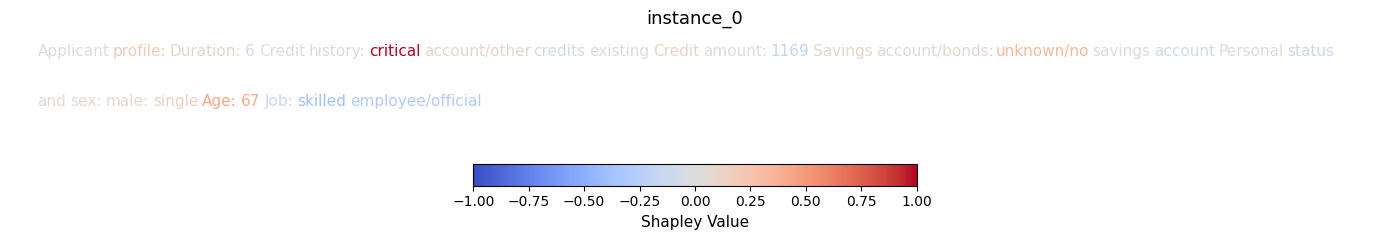


=== instance_1 ===
Applicant profile: Duration: 48 Credit history: existing credits paid back duly Credit amount: 5951 Savings account/bonds: < 100 DM Personal status 
and sex: female: divorced/separated/married Age: 22 Job: skilled employee/official 


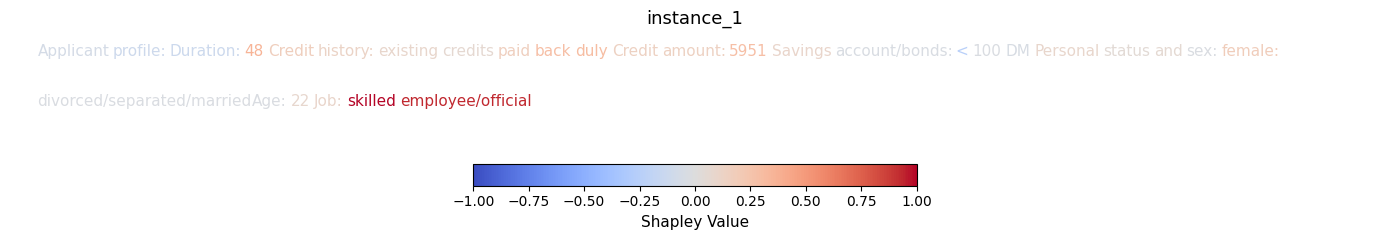


=== instance_4 ===
Applicant profile: Duration: 24 Credit history: delay in paying off in the past Credit amount: 4870 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 53 Job: skilled employee/official 


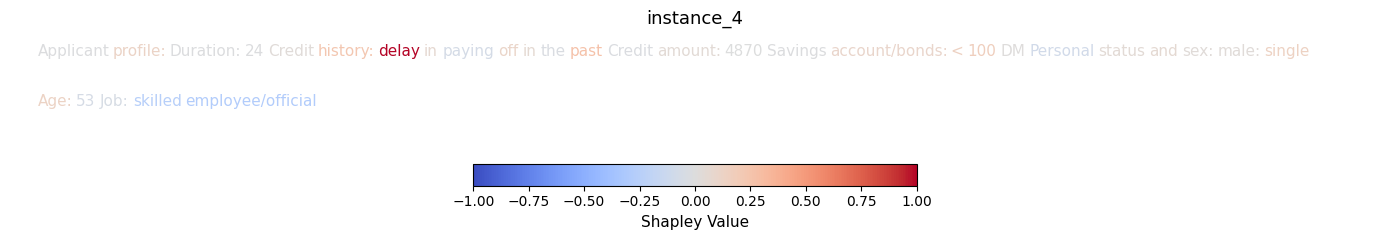


=== instance_9 ===
Applicant profile: Duration: 30 Credit history: critical account/other credits existing Credit amount: 5234 Savings account/bonds: < 100 DM Personal 
status and sex: male: married/widowed Age: 28 Job: management/self-employed/highly qualified 


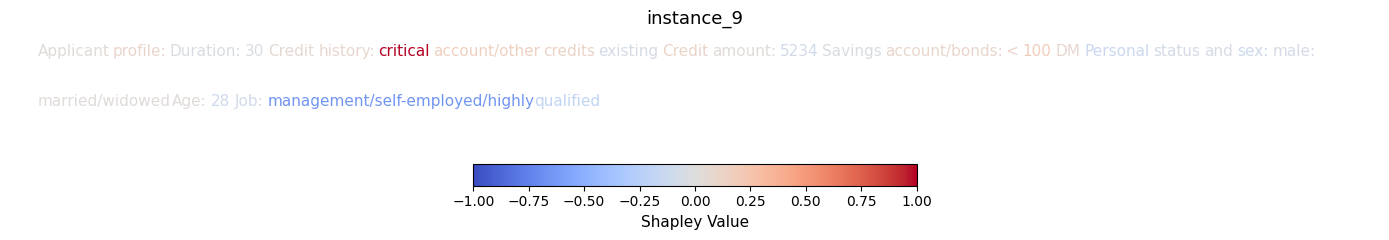


=== instance_17 ===
Applicant profile: Duration: 30 Credit history: no credits/all paid back duly Credit amount: 8072 Savings account/bonds: unknown/no savings account 
Personal status and sex: male: single Age: 25 Job: skilled employee/official 


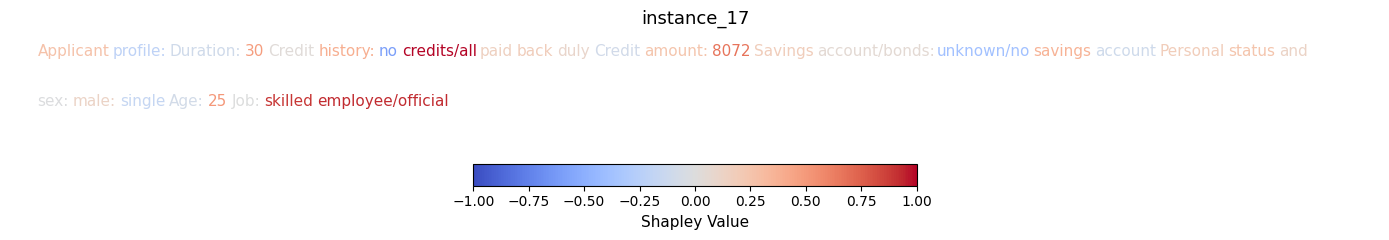


=== instance_29 ===
Applicant profile: Duration: 60 Credit history: delay in paying off in the past Credit amount: 6836 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 63 Job: skilled employee/official 


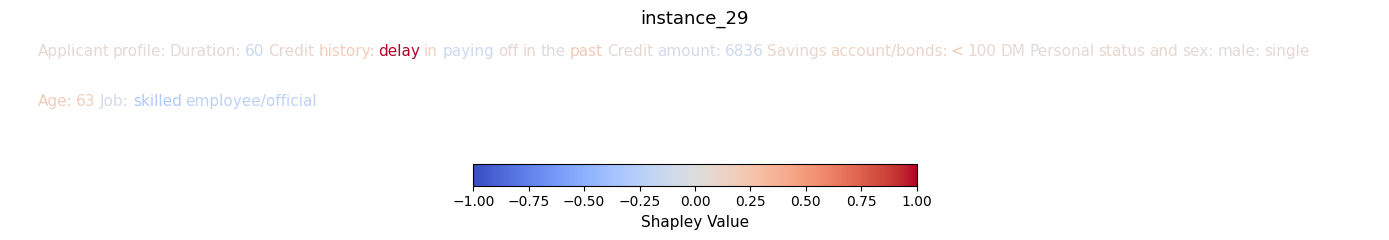


=== instance_55 ===
Applicant profile: Duration: 6 Credit history: all credits at this bank paid back duly Credit amount: 783 Savings account/bonds: unknown/no savings 
account Personal status and sex: male: single Age: 26 Job: unskilled - resident 


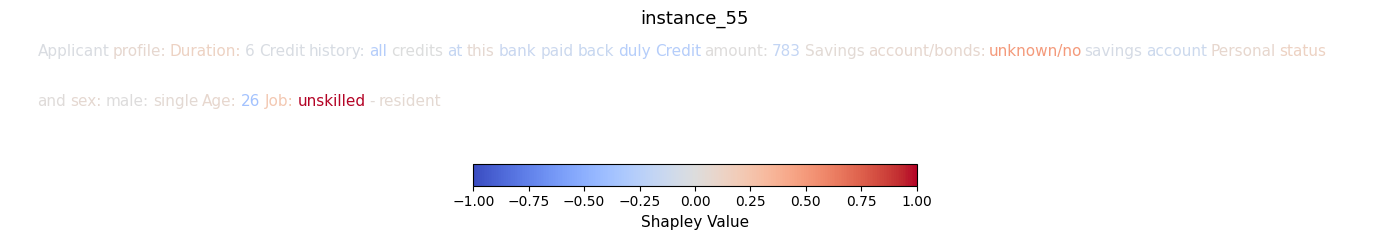


=== instance_95 ===
Applicant profile: Duration: 54 Credit history: no credits/all paid back duly Credit amount: 15945 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 58 Job: skilled employee/official 


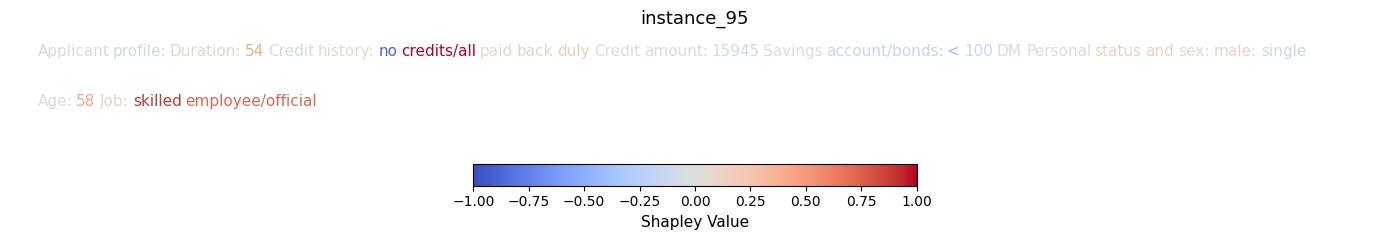


=== instance_107 ===
Applicant profile: Duration: 12 Credit history: existing credits paid back duly Credit amount: 6078 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 32 Job: skilled employee/official 


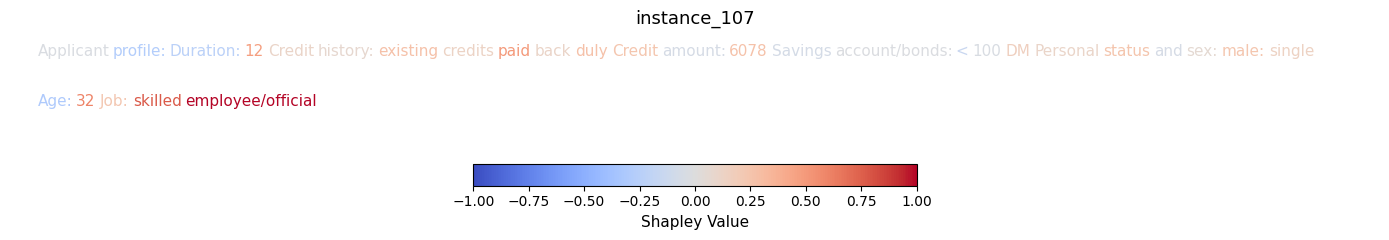


=== instance_134 ===
Applicant profile: Duration: 60 Credit history: existing credits paid back duly Credit amount: 10144 Savings account/bonds: 100-500 DM Personal 
status and sex: female: divorced/separated/married Age: 21 Job: skilled employee/official 


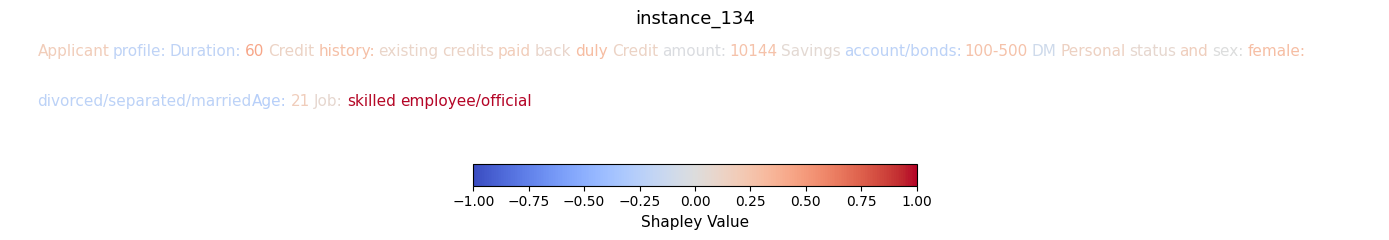


=== instance_186 ===
Applicant profile: Duration: 9 Credit history: all credits at this bank paid back duly Credit amount: 5129 Savings account/bonds: < 100 DM Personal 
status and sex: female: divorced/separated/married Age: 74 Job: management/self-employed/highly qualified 


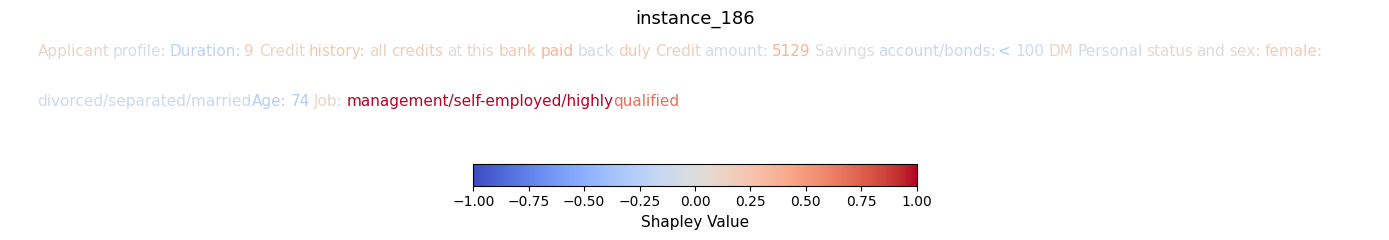


=== instance_226 ===
Applicant profile: Duration: 48 Credit history: existing credits paid back duly Credit amount: 10961 Savings account/bonds: >= 1000 DM Personal 
status and sex: male: single Age: 27 Job: skilled employee/official 


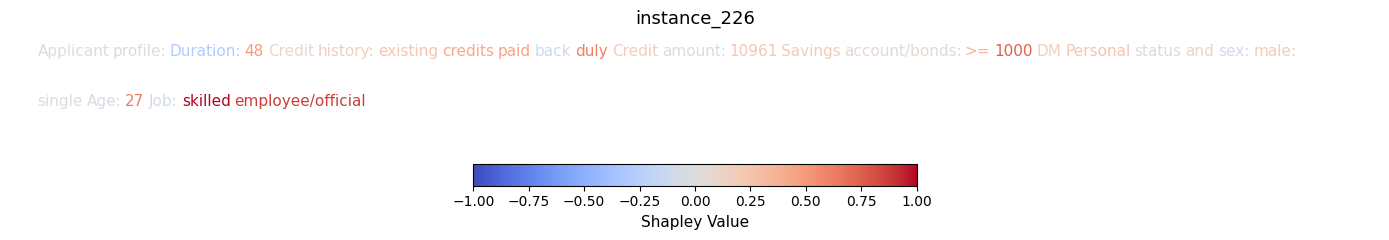


=== instance_236 ===
Applicant profile: Duration: 6 Credit history: existing credits paid back duly Credit amount: 14555 Savings account/bonds: unknown/no savings account 
Personal status and sex: male: single Age: 23 Job: unemployed/unskilled - non-resident 


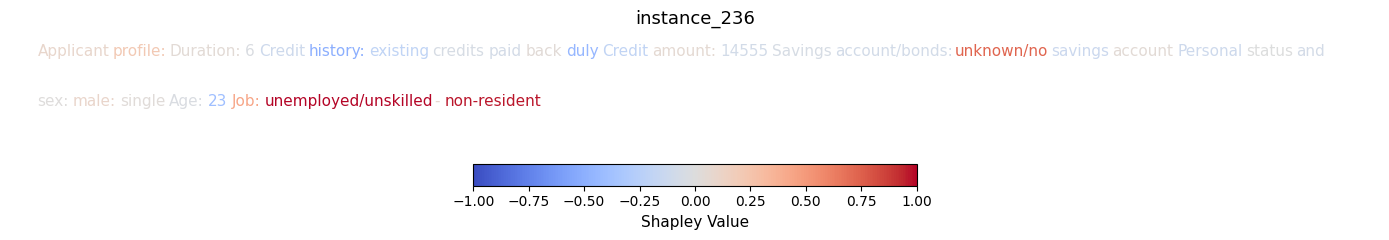


=== instance_300 ===
Applicant profile: Duration: 6 Credit history: existing credits paid back duly Credit amount: 672 Savings account/bonds: < 100 DM Personal status and 
sex: female: divorced/separated/married Age: 54 Job: unemployed/unskilled - non-resident 


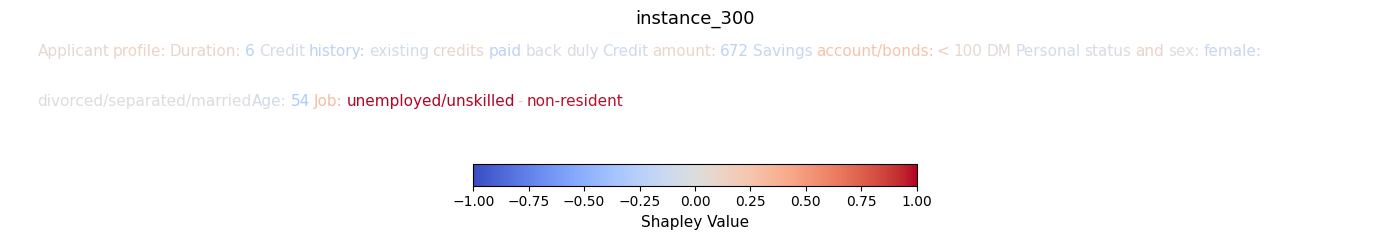


=== instance_430 ===
Applicant profile: Duration: 5 Credit history: existing credits paid back duly Credit amount: 3448 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 74 Job: unskilled - resident 


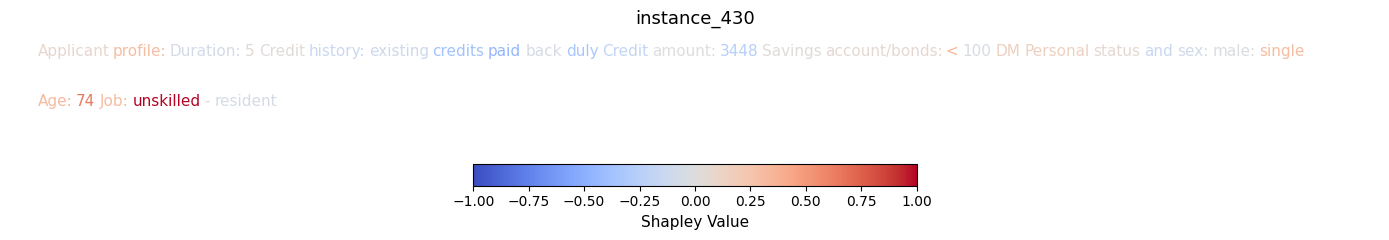


=== instance_615 ===
Applicant profile: Duration: 48 Credit history: no credits/all paid back duly Credit amount: 12204 Savings account/bonds: unknown/no savings account 
Personal status and sex: male: single Age: 48 Job: management/self-employed/highly qualified 


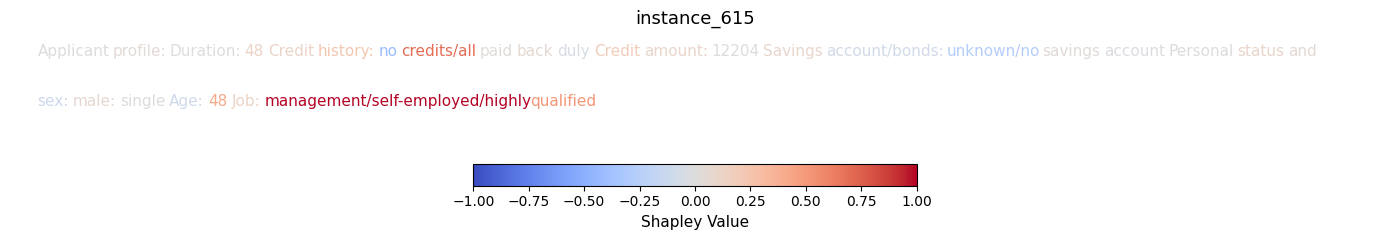


=== instance_671 ===
Applicant profile: Duration: 36 Credit history: existing credits paid back duly Credit amount: 5742 Savings account/bonds: 100-500 DM Personal status 
and sex: male: single Age: 31 Job: skilled employee/official 


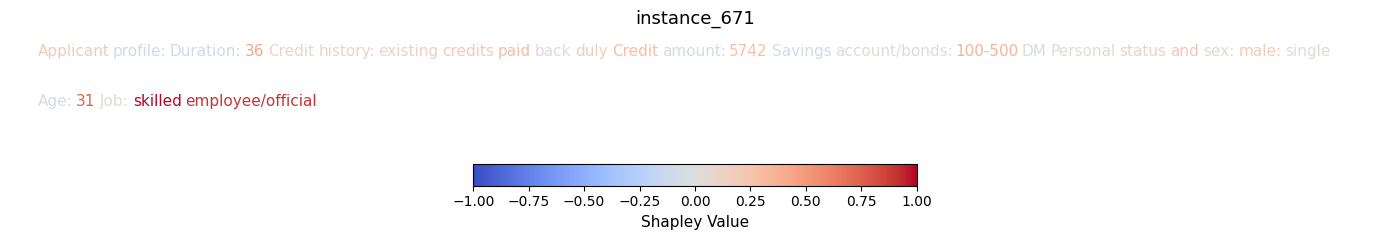


=== instance_887 ===
Applicant profile: Duration: 48 Credit history: existing credits paid back duly Credit amount: 15672 Savings account/bonds: < 100 DM Personal status 
and sex: male: single Age: 23 Job: skilled employee/official 


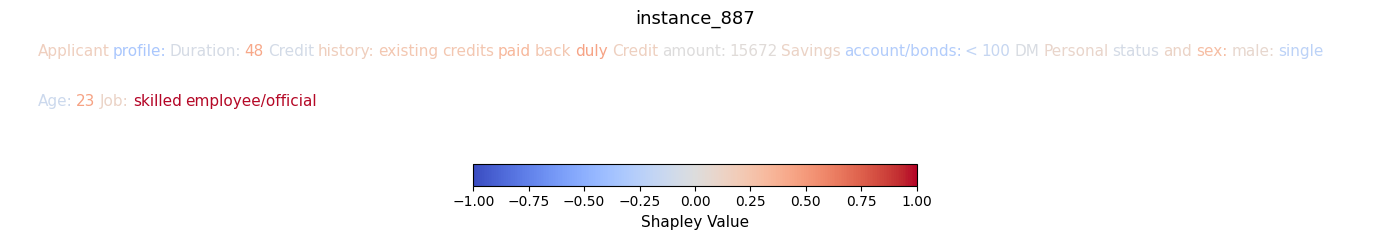


=== instance_915 ===
Applicant profile: Duration: 48 Credit history: no credits/all paid back duly Credit amount: 18424 Savings account/bonds: < 100 DM Personal status 
and sex: female: divorced/separated/married Age: 32 Job: management/self-employed/highly qualified 


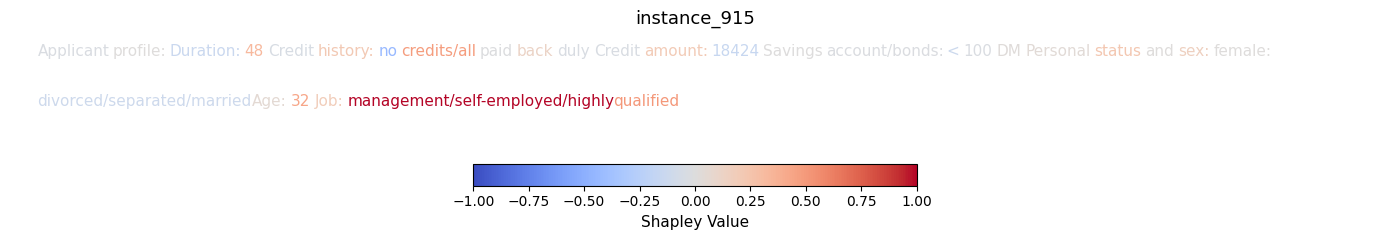


=== instance_999 ===
Applicant profile: Duration: 45 Credit history: critical account/other credits existing Credit amount: 4576 Savings account/bonds: 100-500 DM 
Personal status and sex: male: single Age: 27 Job: skilled employee/official 


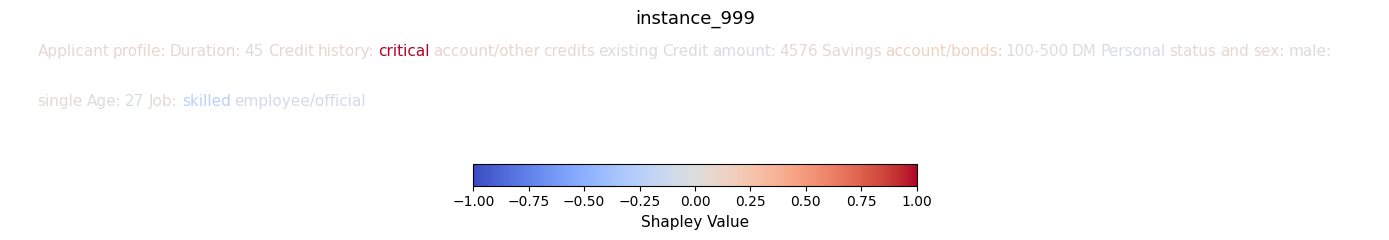

In [47]:
# 1. Update the folder path to include the 'shapley' subfolder
save_dir = os.path.join('visualisations', 'shapley')
os.makedirs(save_dir, exist_ok=True)

for instance_id, df in sorted(dfs.items()):
    print(f"\n=== instance_{instance_id} ===")
    df_ordered = df.sort_values("position")  # original sentence order

    # Print to terminal
    print_colored_text(df_ordered)
    
    # 2. Point the save_file to the new directory
    save_file = os.path.join(save_dir, f"shapley_values_{instance_id}.svg")

    # Plot and save
    plot_colored_text(df_ordered, title=f"instance_{instance_id}", save_path=save_file)

## 5.2 Narrative evaluation

In [48]:
os.makedirs("visualisations/evaluation", exist_ok=True)

### Plot 1: Evaluation heatmaps

In [49]:
# ---------------------------------------------------------------------------
# Helper — extract scores from a single entry
# Returns: {aspect: {model: score}}
# ---------------------------------------------------------------------------
def extract_scores(entry: dict, persona: str) -> dict:
    scores = {}
    for aspect in ASPECTS:
        scores[aspect] = {}
        aspect_data = entry["evaluations"][persona].get(aspect, {})
        for model in MODELS:
            model_data = aspect_data.get(model, {})
            scores[aspect][model] = model_data.get("final_score", None)
    return scores

In [50]:
# ---------------------------------------------------------------------------
# PLOT 1 — Per-instance heatmaps
# Rows: judge models + aggregate row, Cols: aspects
# One image per persona, one heatmap per instance
# ---------------------------------------------------------------------------
short_models = [m.split("/")[-1] for m in MODELS]
row_labels   = short_models + ["Aggregate"]
n_instances  = len(instances)

for persona in personas:
    persona_entries = {e["instance_index"]: e for e in log_evaluated
                       if persona in e.get("evaluations", {})}

    fig1, axes1 = plt.subplots(n_instances, 1, figsize=(6, 2.2 * n_instances))
    if n_instances == 1:
        axes1 = [axes1]

    for ax_idx, instance in enumerate(instances):
        ax    = axes1[ax_idx]
        entry = persona_entries.get(instance)

        if entry is None:
            ax.set_visible(False)
            continue

        scores = extract_scores(entry, persona)

        # Individual judge rows — same as before
        judge_matrix = np.array([
            [scores[aspect].get(model, np.nan) for aspect in ASPECTS]
            for model in MODELS
        ], dtype=float)

        # Aggregate row
        agg_row = np.array([
            entry["evaluations"][persona].get(aspect, {}).get("aggregate_score", np.nan)
            for aspect in ASPECTS
        ], dtype=float).reshape(1, -1)

        matrix = np.vstack([judge_matrix, agg_row])

        # Draw dividing line between judges and aggregate
        # by using a masked annotation style: bold for aggregate row
        sns.heatmap(
            matrix,
            ax=ax,
            annot=True,
            fmt=".1f",
            vmin=1, vmax=5,
            cmap="RdYlGn",
            xticklabels=[a.capitalize() for a in ASPECTS],
            yticklabels=row_labels,
            linewidths=0.5,
            linecolor="white",
            cbar=False,
        )

        # Bold the aggregate row label and draw a separator line
        yticklabels = ax.get_yticklabels()
        yticklabels[-1].set_fontweight("bold")
        ax.set_yticklabels(yticklabels)

        # Horizontal separator above aggregate row
        ax.axhline(y=len(MODELS), color="black", linewidth=1.5)

        ax.set_title(f"Instance {instance}", fontsize=11,
                     fontweight="bold", pad=8)
        ax.set_ylabel("")
        ax.set_xlabel("Aspect")

    fig1.suptitle(
        f"Per-Instance Evaluation Scores — {persona.replace('_', ' ').title()}",
        fontsize=14, fontweight="bold", y=1.02
    )
    fig1.tight_layout()
    fig1.subplots_adjust(top=1)

    filename = f"visualisations/evaluation/evaluation_heatmaps_{persona}.svg"
    fig1.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved {filename}")
    plt.close(fig1)

Saved visualisations/evaluation/evaluation_heatmaps_bank_client.svg
Saved visualisations/evaluation/evaluation_heatmaps_bank_officer.svg
Saved visualisations/evaluation/evaluation_heatmaps_expert_judge.svg


####    Plot 1b: Aggregate heatmap

In [51]:
# ---------------------------------------------------------------------------
# PLOT 1b — Heatmap: instances (rows) x aspects (cols)
# Value: aggregate_score averaged across personas
# Good for spotting outlier instances at a glance
# ---------------------------------------------------------------------------

# Build: instance -> aspect -> mean aggregate score across personas
instance_aspect_means = {}
for instance in instances:
    instance_aspect_means[instance] = {}
    for aspect in ASPECTS:
        scores = [
            e["evaluations"][persona].get(aspect, {}).get("aggregate_score")
            for e in log_evaluated
            if e["instance_index"] == instance
            for persona in personas
            if persona in e.get("evaluations", {})
            and e["evaluations"][persona].get(aspect, {}).get("aggregate_score") is not None
        ]
        instance_aspect_means[instance][aspect] = np.mean(scores) if scores else np.nan
        
matrix = np.array([
    [instance_aspect_means[inst][aspect] for aspect in ASPECTS]
    for inst in instances
])

fig, ax = plt.subplots(figsize=(5, max(6, len(instances) * 0.4)))
sns.heatmap(
    matrix,
    ax=ax,
    annot=True,
    fmt=".1f",
    vmin=1, vmax=5,
    cmap="RdYlGn",
    xticklabels=[a.capitalize() for a in ASPECTS],
    yticklabels=[f"#{inst}" for inst in instances],
    linewidths=0.4,
    cbar_kws={"label": "Aggregate score"},
)
ax.set_title("Aggregate Score Heatmap", fontweight="bold")
ax.set_xlabel("Aspect")
ax.set_ylabel("Instance")

fig.tight_layout()
fig.savefig("visualisations/evaluation/aggregate_heatmap.svg", dpi=150, bbox_inches="tight")
print("Saved aggregate_heatmap.svg")
plt.close(fig)

Saved aggregate_heatmap.svg


### Plot 2: Average scores (over all instances) per Judge and Persona

In [52]:
rows = []
for e in log_evaluated:
    instance = e["instance_index"]
    for persona, aspects in e["evaluations"].items():
        for aspect, models_data in aspects.items():
            for model in MODELS:
                data = models_data.get(model, {})
                score = data.get("final_score") if isinstance(data, dict) else None
                rows.append({
                    "instance": instance,
                    "persona": persona.replace("_", " ").title(),
                    "aspect": aspect.capitalize(),
                    "model": model.split("/")[-1],
                    "score": score,
                })

df_long = pd.DataFrame(rows).dropna(subset=["score"])

strip plot

In [53]:
fig, axes = plt.subplots(1, len(ASPECTS), figsize=(5 * len(ASPECTS), 5), sharey=True)

for i, (ax, aspect) in enumerate(zip(axes, ASPECTS)):
    data = df_long[df_long["aspect"] == aspect.capitalize()]
    sns.stripplot(
        data=data, x="persona", y="score", hue="model",
        dodge=True, jitter=0.15, ax=ax, alpha=0.5, size=6,
    )
    ax.set_title(aspect.capitalize(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score (1-5)" if i == 0 else "")
    ax.set_ylim(0.5, 5.5)
    ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis="x", rotation=20)

    if aspect.lower() != "plausibility":
        ax.legend_.remove()
    else:
        ax.legend(title="Judge", fontsize=7, title_fontsize=8, loc="lower right")

fig.suptitle("Score Distribution per Persona & Judge", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("visualisations/evaluation/strip_all_judges.svg", dpi=150, bbox_inches="tight")
plt.close(fig)

bar chart

In [54]:
cmap_models = matplotlib.colormaps.get_cmap("tab10")
colors_personas = [cmap_models(i / len(personas)) for i in range(len(personas))]

n_personas = len(personas)
width = min(0.25, 0.8 / n_personas)
bar_fig_width = max(6, n_personas * len(ASPECTS) * 0.6 + 2)

for model in MODELS:
    short_model = model.split("/")[-1]

    fig_bar, ax_bar = plt.subplots(figsize=(bar_fig_width, 5))

    persona_aspect_means = {}
    for persona in personas:
        persona_entries = [e for e in log_evaluated if persona in e.get("evaluations", {})]
        means = {}
        for aspect in ASPECTS:
            scores = [
                e["evaluations"][persona].get(aspect, {}).get(model, {}).get("final_score")
                for e in persona_entries
                if isinstance(e["evaluations"][persona].get(aspect, {}).get(model, {}), dict)
                and e["evaluations"][persona].get(aspect, {}).get(model, {}).get("final_score") is not None
            ]
            means[aspect] = np.mean(scores) if scores else 0
        persona_aspect_means[persona] = means

    x = np.arange(len(ASPECTS))

    for i, (persona, means) in enumerate(persona_aspect_means.items()):
        values = [means[a] for a in ASPECTS]
        offset = (i - n_personas / 2 + 0.5) * width
        bars = ax_bar.bar(
            x + offset, values, width,
            label=persona.replace("_", " ").title(),
            color=colors_personas[i], alpha=0.85
        )
        for bar, val in zip(bars, values):
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9
            )

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels([a.capitalize() for a in ASPECTS])
    ax_bar.set_ylim(0.5, 5.5)
    ax_bar.set_xlim(-0.5, len(ASPECTS) - 0.5)
    ax_bar.set_ylabel("Average score over all instances")
    ax_bar.set_title(f"Average Scores per Aspect & Persona — {short_model}", fontweight="bold")
    ax_bar.legend()
    ax_bar.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

    fig_bar.tight_layout()
    filename_bar = f"visualisations/evaluation/evaluation_summary_bar_{short_model}.svg"
    fig_bar.savefig(filename_bar, dpi=150, bbox_inches="tight")
    print(f"Saved {filename_bar}")
    plt.close(fig_bar)

Saved visualisations/evaluation/evaluation_summary_bar_gpt-5.4.svg
Saved visualisations/evaluation/evaluation_summary_bar_gemini-3.1-pro-preview.svg
Saved visualisations/evaluation/evaluation_summary_bar_claude-sonnet-4.6.svg
Saved visualisations/evaluation/evaluation_summary_bar_grok-4.20.svg


#### Plot 2b: Average scores (over all instances) of aggregated scores per Persona

The aggregate score is the majority-voted score across all judge models for a given aspect and instance — so if 3 out of 5 models give a score of 2, the aggregate score is 2. The averaged aggregate score in the bar chart then takes these per-instance aggregate scores and averages them across all 20 instances to give a single summary score per aspect per persona.

In [55]:
n_personas = len(personas)
width = min(0.25, 0.8 / n_personas)
fig_width = max(6, n_personas * len(ASPECTS) * 0.6 + 2)

cmap   = matplotlib.colormaps.get_cmap("tab10")
colors = [cmap(i / len(personas)) for i in range(len(personas))]

persona_aspect_means = {}
for persona in personas:
    persona_entries = [e for e in log_evaluated if persona in e.get("evaluations", {})]
    means = {}
    for aspect in ASPECTS:
        agg_scores = [
            e["evaluations"][persona].get(aspect, {}).get("aggregate_score")
            for e in persona_entries
            if e["evaluations"][persona].get(aspect, {}).get("aggregate_score") is not None
        ]
        means[aspect] = np.mean(agg_scores) if agg_scores else 0
    persona_aspect_means[persona] = means

x = np.arange(len(ASPECTS))

fig_bar, ax_bar = plt.subplots(figsize=(fig_width, 5))

for i, (persona, means) in enumerate(persona_aspect_means.items()):
    values = [means[a] for a in ASPECTS]
    offset = (i - n_personas / 2 + 0.5) * width
    bars = ax_bar.bar(x + offset, values, width,
                      label=persona.replace("_", " ").title(),
                      color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([a.capitalize() for a in ASPECTS])
ax_bar.set_ylim(0.5, 5.5)
ax_bar.set_xlim(-0.5, len(ASPECTS) - 0.5)
ax_bar.set_ylabel("Average score over all instances")
ax_bar.set_title("Average Aggregate Scores per Aspect & Persona", fontweight="bold")
ax_bar.legend()
ax_bar.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

fig_bar.tight_layout()
fig_bar.savefig("visualisations/evaluation/evaluation_summary_bar.svg", dpi=150, bbox_inches="tight")
print("Saved visualisations/evaluation/evaluation_summary_bar.svg")
plt.close(fig_bar)

Saved visualisations/evaluation/evaluation_summary_bar.svg


### Plot 3: Average aggregate score per aspect

In [56]:
# ---------------------------------------------------------------------------
# PLOT 3 — Single bar chart: average aggregate score per aspect
# Averaged across all instances AND all personas — the headline result
# ---------------------------------------------------------------------------
aspect_means = {}
aspect_sems  = {}

for aspect in ASPECTS:
    scores = [
        e["evaluations"][persona].get(aspect, {}).get("aggregate_score")
        for e in log_evaluated
        for persona in personas
        if persona in e.get("evaluations", {})
        and e["evaluations"][persona].get(aspect, {}).get("aggregate_score") is not None
    ]
    aspect_means[aspect] = np.mean(scores)
    aspect_sems[aspect]  = np.std(scores, ddof=1) / np.sqrt(len(scores))

colors_aspects = ["#4C72B0", "#DD8452", "#55A868"]
fig, ax = plt.subplots(figsize=(5, 5))

x = np.arange(len(ASPECTS))
bars = ax.bar(
    x,
    [aspect_means[a] for a in ASPECTS],
    yerr=[aspect_sems[a] for a in ASPECTS],
    color=colors_aspects,
    alpha=0.85,
    capsize=5,
    width=0.5,
)
for bar, aspect in zip(bars, ASPECTS):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + aspect_sems[aspect] + 0.08,
        f"{aspect_means[aspect]:.2f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels([a.capitalize() for a in ASPECTS], fontsize=12)
ax.set_ylim(0.5, 5.5)
ax.set_ylabel("Average aggregate score (1–5)", fontsize=11)
ax.set_title("Average Aggregate Scores", fontweight="bold")
ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig("visualisations/evaluation/aggregate_headline.svg", dpi=150, bbox_inches="tight")
print("Saved aggregate_headline.svg")
plt.close(fig)

Saved aggregate_headline.svg


### Plot 4: Per persona and instance comparison between llm judges

In [57]:
short_models = [m.split("/")[-1] for m in MODELS]
bar_width    = 0.15
colors       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for persona in personas:
    persona_entries = {e["instance_index"]: e for e in log_evaluated if persona in e.get("evaluations", {})}

    fig, axes = plt.subplots(len(ASPECTS), 1, figsize=(14, 5 * len(ASPECTS)), sharey=True)

    if len(ASPECTS) == 1:
        axes = [axes]

    for ax, aspect in zip(axes, ASPECTS):
        x_positions = np.arange(len(instances))

        for k, model in enumerate(MODELS):
            short_model = short_models[k]
            scores = []
            for instance in instances:
                entry = persona_entries.get(instance)
                if entry:
                    model_data = entry["evaluations"][persona].get(aspect, {}).get(model, {})
                    score = model_data.get("final_score") if isinstance(model_data, dict) else None
                    scores.append(score if score is not None else 0)
                else:
                    scores.append(0)

            offset = (k - len(MODELS) / 2 + 0.5) * bar_width
            bars = ax.bar(
                x_positions + offset, scores,
                width=bar_width,
                label=short_model,
                color=colors[k],
                alpha=0.85,
            )

            for bar, score in zip(bars, scores):
                if score > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.05,
                        str(int(score)),
                        ha="center", va="bottom", fontsize=7
                    )

        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"#{idx}" for idx in instances], fontsize=9)
        ax.set_title(aspect.capitalize(), fontweight="bold")
        ax.set_xlabel("Instance")
        ax.set_ylabel("Score (1-5)")
        ax.set_ylim(0.5, 5.5)
        ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    handles = [
        mpatches.Patch(color=colors[k], label=short_models[k])
        for k in range(len(MODELS))
    ]
    fig.legend(handles=handles, title="Judge Model", fontsize=8,
               loc="lower center", ncol=len(MODELS),
               bbox_to_anchor=(0.5, -0.05))

    fig.suptitle(
        f"Per-LLM Scores — {persona.replace('_', ' ').title()}",
        fontsize=14, fontweight="bold", y=1.02
    )
    fig.tight_layout()

    filename = f"visualisations/evaluation/evaluation_llm_scores_{persona}.svg"
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved {filename}")
    plt.close(fig)

Saved visualisations/evaluation/evaluation_llm_scores_bank_client.svg
Saved visualisations/evaluation/evaluation_llm_scores_bank_officer.svg
Saved visualisations/evaluation/evaluation_llm_scores_expert_judge.svg


### Plot 5: Per llm judge and instance comparison between personas

In [58]:
short_personas = [p.replace("_", " ").title() for p in personas]
bar_width      = 0.15
colors_p       = ["#4C72B0", "#DD8452", "#55A868"]

for model in MODELS:
    short_model = model.split("/")[-1]

    fig, axes = plt.subplots(len(ASPECTS), 1, figsize=(14, 5 * len(ASPECTS)), sharey=True)

    if len(ASPECTS) == 1:
        axes = [axes]

    for ax, aspect in zip(axes, ASPECTS):
        x_positions = np.arange(len(instances))

        for k, persona in enumerate(personas):
            persona_entries = {e["instance_index"]: e for e in log_evaluated if persona in e.get("evaluations", {})}
            scores = []
            for instance in instances:
                entry = persona_entries.get(instance)
                if entry:
                    model_data = entry["evaluations"][persona].get(aspect, {}).get(model, {})
                    score = model_data.get("final_score") if isinstance(model_data, dict) else None
                    scores.append(score if score is not None else 0)
                else:
                    scores.append(0)

            offset = (k - len(personas) / 2 + 0.5) * bar_width
            bars = ax.bar(
                x_positions + offset, scores,
                width=bar_width,
                label=short_personas[k],
                color=colors_p[k],
                alpha=0.85,
            )

            for bar, score in zip(bars, scores):
                if score > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.05,
                        str(int(score)),
                        ha="center", va="bottom", fontsize=7
                    )

        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"#{idx}" for idx in instances], fontsize=9)
        ax.set_title(aspect.capitalize(), fontweight="bold")
        ax.set_xlabel("Instance")
        ax.set_ylabel("Score (1-5)")
        ax.set_ylim(0.5, 5.5)
        ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    handles = [
        mpatches.Patch(color=colors_p[k], label=short_personas[k])
        for k in range(len(personas))
    ]
    fig.legend(handles=handles, title="Persona", fontsize=8,
               loc="lower center", ncol=len(personas),
               bbox_to_anchor=(0.5, -0.05))

    fig.suptitle(
        f"Per-Persona Scores — {short_model}",
        fontsize=14, fontweight="bold", y=1.02
    )
    fig.tight_layout()

    filename = f"visualisations/evaluation/evaluation_persona_scores_{short_model}.svg"
    fig.savefig(filename, dpi=150, bbox_inches="tight")
    print(f"Saved {filename}")
    plt.close(fig)

Saved visualisations/evaluation/evaluation_persona_scores_gpt-5.4.svg
Saved visualisations/evaluation/evaluation_persona_scores_gemini-3.1-pro-preview.svg
Saved visualisations/evaluation/evaluation_persona_scores_claude-sonnet-4.6.svg
Saved visualisations/evaluation/evaluation_persona_scores_grok-4.20.svg


####    Plot 5b: Aggregate scores per persona

In [59]:
# ---------------------------------------------------------------------------
# PLOT 5b — Aggregate scores per instance, coloured by persona
# 3 subplots (one per aspect), one figure total
# Replaces the per-persona loop with a single comparable figure
# ---------------------------------------------------------------------------
colors_p  = ["#4C72B0", "#DD8452", "#55A868"]
bar_width = 0.25

fig, axes = plt.subplots(len(ASPECTS), 1,
                         figsize=(max(14, len(instances) * 0.8),
                                  5 * len(ASPECTS)),
                         sharey=True)

if len(ASPECTS) == 1:
    axes = [axes]

for ax, aspect in zip(axes, ASPECTS):
    x_positions = np.arange(len(instances))

    for k, persona in enumerate(personas):
        persona_entries = {e["instance_index"]: e for e in log_evaluated
                           if persona in e.get("evaluations", {})}
        scores = []
        for instance in instances:
            entry = persona_entries.get(instance)
            if entry:
                val = entry["evaluations"][persona].get(
                    aspect, {}).get("aggregate_score")
                scores.append(val if val is not None else 0)
            else:
                scores.append(0)

        offset = (k - len(personas) / 2 + 0.5) * bar_width
        bars = ax.bar(
            x_positions + offset, scores,
            width=bar_width,
            label=persona.replace("_", " ").title(),
            color=colors_p[k % len(colors_p)],
            alpha=0.85,
        )
        for bar, score in zip(bars, scores):
            if score > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f"{score:.1f}",
                    ha="center", va="bottom", fontsize=7
                )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"#{inst}" for inst in instances],
                       fontsize=9, rotation=45, ha="right")
    ax.set_title(aspect.capitalize(), fontweight="bold")
    ax.set_xlabel("Instance")
    ax.set_ylabel("Aggregate score (1–5)")
    ax.set_ylim(0.5, 5.5)
    ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

handles = [
    mpatches.Patch(color=colors_p[k % len(colors_p)],
                   label=personas[k].replace("_", " ").title())
    for k in range(len(personas))
]
fig.legend(handles=handles, title="Persona", fontsize=8,
           loc="lower center", ncol=len(personas),
           bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    "Aggregate Scores per Instance & Persona",
    fontsize=14, fontweight="bold", y=1.02
)
fig.tight_layout()
fig.savefig("visualisations/evaluation/aggregate_persona_per_instance.svg",
            dpi=150, bbox_inches="tight")
print("Saved aggregate_persona_per_instance.svg")
plt.close(fig)

Saved aggregate_persona_per_instance.svg


### Plot 6: All metrics averaged per Persona, Judge, Instance

In [60]:
n_cols = 4
n_rows = math.ceil(len(instances) / n_cols)
short_models = [m.split("/")[-1] for m in MODELS]
bar_width = 0.15
colors       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=True)
axes_flat  = axes.flatten()

for ax in axes_flat[len(instances):]:
    ax.set_visible(False)

for ax, instance in zip(axes_flat, instances):
    x_positions = np.arange(len(personas))

    for k, model in enumerate(MODELS):
        short_model = short_models[k]
        scores = []

        for persona in personas:
            persona_entries = {e["instance_index"]: e for e in log_evaluated if persona in e.get("evaluations", {})}
            entry = persona_entries.get(instance)
            if entry:
                aspect_scores = []
                for aspect in ASPECTS:
                    model_data = entry["evaluations"][persona].get(aspect, {}).get(model, {})
                    score = model_data.get("final_score") if isinstance(model_data, dict) else None
                    if score is not None:
                        aspect_scores.append(score)
                scores.append(np.mean(aspect_scores) if aspect_scores else 0)
            else:
                scores.append(0)

        offset = (k - len(MODELS) / 2 + 0.5) * bar_width
        bars = ax.bar(
            x_positions + offset, scores,
            width=bar_width,
            label=short_model,
            color=colors[k],
            alpha=0.85,
        )

        for bar, score in zip(bars, scores):
            if score > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.05,
                    f"{score:.1f}",
                    ha="center", va="bottom", fontsize=6
                )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [p.replace("_", " ").title() for p in personas],
        fontsize=8
    )
    ax.set_title(f"Instance #{instance}", fontweight="bold", fontsize=10)
    ax.set_ylim(0.5, 5.5)
    ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

for ax in axes_flat[::n_cols]:
    ax.set_ylabel("Avg. score across all aspects")

handles = [
    mpatches.Patch(color=colors[k], label=short_models[k])
    for k in range(len(MODELS))
]
fig.legend(handles=handles, title="Judge Model", fontsize=8,
            loc="lower center", ncol=len(MODELS),
            bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    "Average score across all aspects per Persona, Judge and Instance\n"
    "(faithfulness, helpfulness and plausibility averaged)",
    fontsize=14, fontweight="bold", y=1.02
)
fig.tight_layout()
fig.savefig("visualisations/evaluation/evaluation_faceted.svg", dpi=150, bbox_inches="tight")
print("Saved visualisations/evaluation/evaluation_faceted.svg")
plt.close(fig)

Saved visualisations/evaluation/evaluation_faceted.svg


### Plot 7: Score distribution per judge across all aspects and personas

Saved visualisations/evaluation/score_distribution.svg


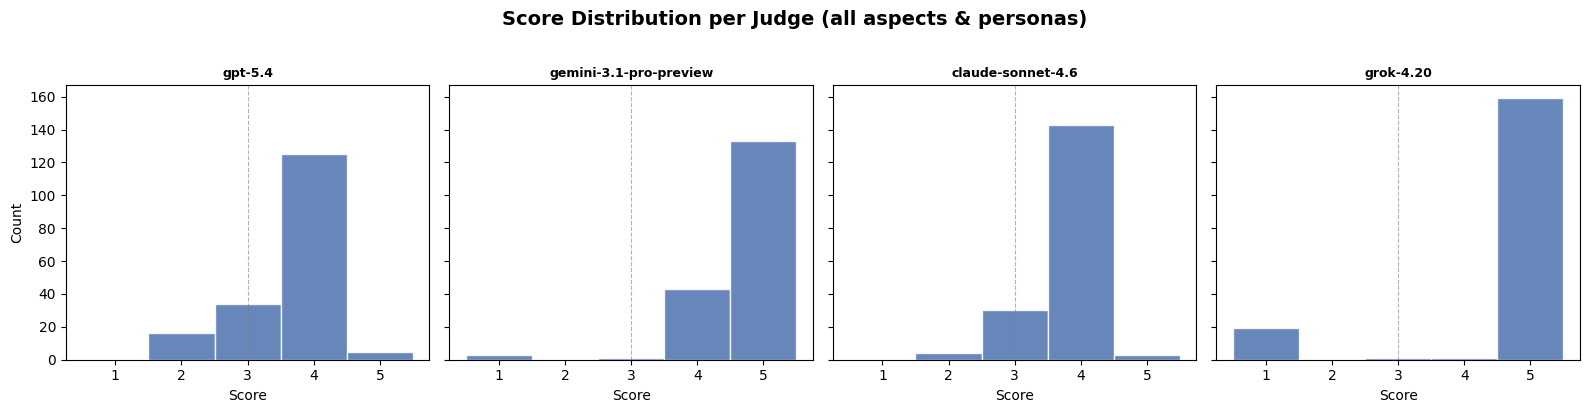

In [61]:
short_models = [m.split("/")[-1] for m in MODELS]

fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 4), sharey=True)

for ax, model in zip(axes, MODELS):
    short_model = model.split("/")[-1]
    scores = []

    for e in log_evaluated:
        for persona in personas:
            if persona not in e.get("evaluations", {}):
                continue
            for aspect in ASPECTS:
                data = e["evaluations"][persona].get(aspect, {}).get(model, {})
                score = data.get("final_score") if isinstance(data, dict) else None
                if score is not None:
                    scores.append(score)

    ax.hist(scores, bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(short_model, fontweight="bold", fontsize=9)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count" if ax == axes[0] else "")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.axvline(x=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

fig.suptitle("Score Distribution per Judge (all aspects & personas)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("visualisations/evaluation/score_distribution.svg", dpi=150, bbox_inches="tight")
print("Saved visualisations/evaluation/score_distribution.svg")

####    Plot 7b: Aggregate score distribution

In [62]:
# ---------------------------------------------------------------------------
# PLOT 7b — Distribution of aggregate scores across all instances,
# aspects and personas — shows overall calibration of the pipeline
# ---------------------------------------------------------------------------
all_agg_scores = [
    e["evaluations"][persona].get(aspect, {}).get("aggregate_score")
    for e in log_evaluated
    for persona in personas
    if persona in e.get("evaluations", {})
    for aspect in ASPECTS
    if e["evaluations"][persona].get(aspect, {}).get("aggregate_score") is not None
]

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(
    all_agg_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color="#4C72B0", edgecolor="white", alpha=0.85
)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("Aggregate score", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Aggregate Score Distribution", fontweight="bold")
ax.axvline(x=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.3)

mean_agg = np.mean(all_agg_scores)
ax.axvline(x=mean_agg, color="#C44E52", linestyle="-", linewidth=1.5, label=f"Mean = {mean_agg:.2f}")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig("visualisations/evaluation/aggregate_distribution.svg", dpi=150, bbox_inches="tight")
print("Saved aggregate_distribution.svg")
plt.close(fig)

Saved aggregate_distribution.svg


### Plot 8: Per instance aggregate scores per aspect

In [63]:
# ---------------------------------------------------------------------------
# PLOT 8 — Per-instance aggregate scores per aspect
# Aggregate_score averaged across personas, shown per instance
# Primary result figure: shows narrative quality across the 20 instances
# ---------------------------------------------------------------------------
colors_aspects = ["#4C72B0", "#DD8452", "#55A868"]
bar_width = 0.25

x_positions = np.arange(len(instances))
fig, ax = plt.subplots(figsize=(max(12, len(instances) * 0.7), 5))

for k, (aspect, color) in enumerate(zip(ASPECTS, colors_aspects)):
    values = [instance_aspect_means[inst][aspect] for inst in instances]
    offset = (k - len(ASPECTS) / 2 + 0.5) * bar_width
    bars = ax.bar(
        x_positions + offset, values,
        width=bar_width, label=aspect.capitalize(),
        color=color, alpha=0.85
    )
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f"{val:.1f}", ha="center", va="bottom", fontsize=7
            )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"#{inst}" for inst in instances], fontsize=9, rotation=45, ha="right")
ax.set_ylim(0.5, 5.5)
ax.set_ylabel("Aggregate score (averaged across personas)", fontsize=10)
ax.set_xlabel("Instance", fontsize=10)
ax.set_title("Per-Instance Aggregate Scores", fontweight="bold")
ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(title="Aspect", fontsize=9, loc="lower left")
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig("visualisations/evaluation/aggregate_per_instance.svg", dpi=150, bbox_inches="tight")
print("Saved aggregate_per_instance.svg")
plt.close(fig)

Saved aggregate_per_instance.svg
